In [84]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src import (
    QlearningGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [ ]:
### RUNNING THE MODEL ### 

#Parameters

"""
  a = the constant in front of the term for probability of exploring in every round (epsilon) 
  b = the decay rate beta 
  alpha = learning rate / step size 
  gamma = discount factor for future rewards 

"""

#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)


#run simulation for FPA or SPA
simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history = simulation.run()

Convergence detected after 70545 rounds.
Bidder Agent1 had converged to  0.2
Bidder Agent2 had converged to  0.2


In [4]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)

#run simulation for SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_SPA = simulation.run()

Convergence detected after 253734 rounds.
Bidder Agent1 had converged to  0.9500000000000001
Bidder Agent2 had converged to  0.9500000000000001


Giving just one example run we see evidence of collusion in the First Price Auction. Whereas the Second Price Auction converges to the NE. Moreover, the FPA takes 80,000 rounds to converge whereas the SPA takes approx. 3x as long to converge in 235,000 rounds.

##### Evolution of q-value for FPA:

In [5]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

Evolution of the q-value associated to the bid the FPA converged to (0.15).

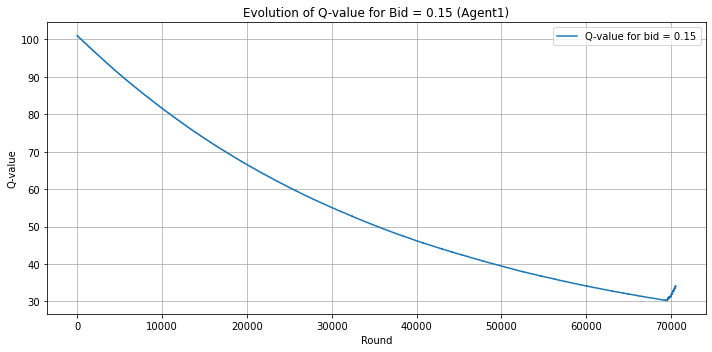

In [15]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 3

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.15")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.15 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now the evolution of the q-value associated to another bid.

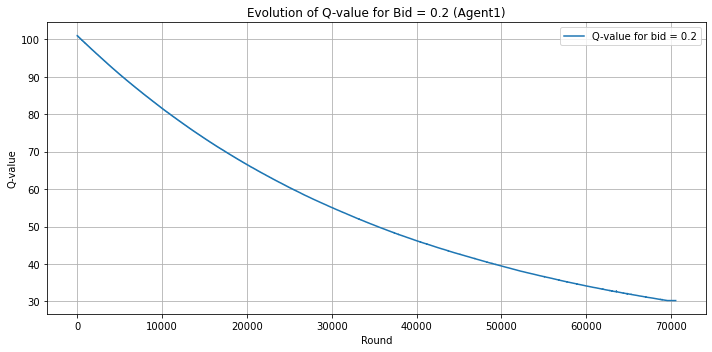

In [16]:
bid_index = 4

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.2")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.2 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now let's look at just the final 5000 rounds to see the evolution in more detail.

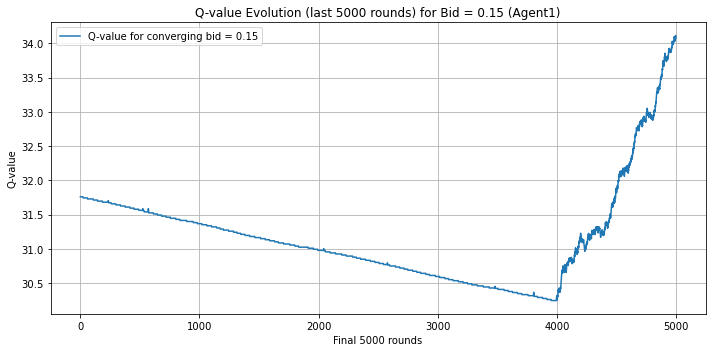

In [ ]:
bid_index = 3
bidder_name = "Agent1"

q_trajectory = extract_q_trajectory(history, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for converging bid = {0.15}")
plt.xlabel("Final 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

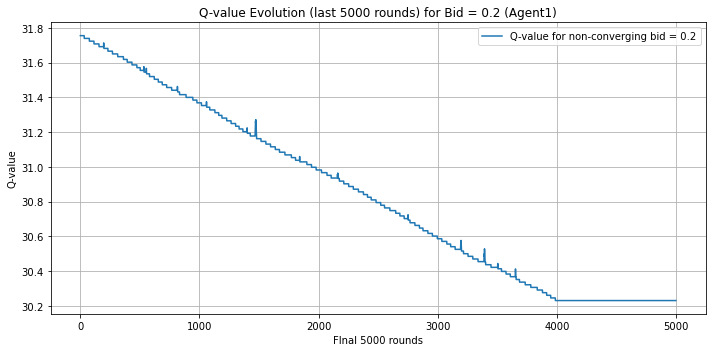

In [18]:
bid_index = 4
bidder_name = "Agent1"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for non-converging bid = {0.2}")
plt.xlabel("FInal 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.2} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

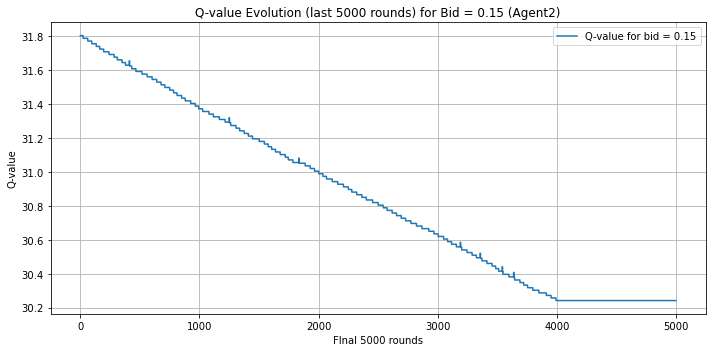

In [10]:
bid_index = 2
bidder_name = "Agent2"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for bid = {0.15}")
plt.xlabel("FInal 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Q-value evolution for SPA:

Had winning bid 0.95 (has index 18).

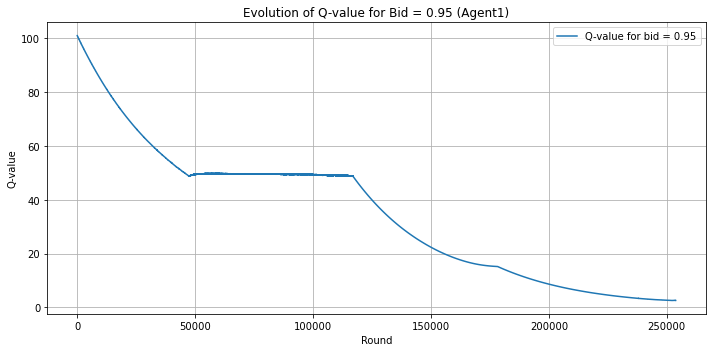

In [19]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 18

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.95")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.95 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

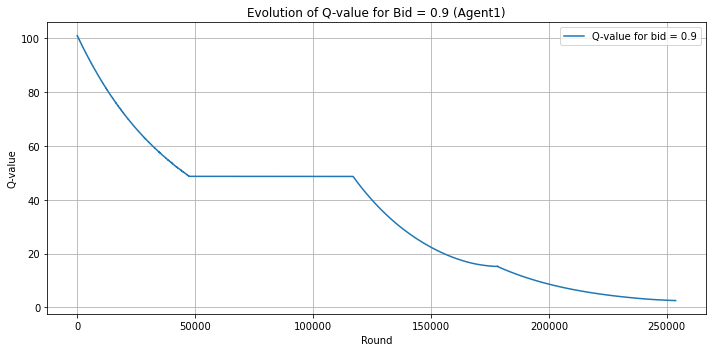

In [12]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 17

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.9")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.9 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

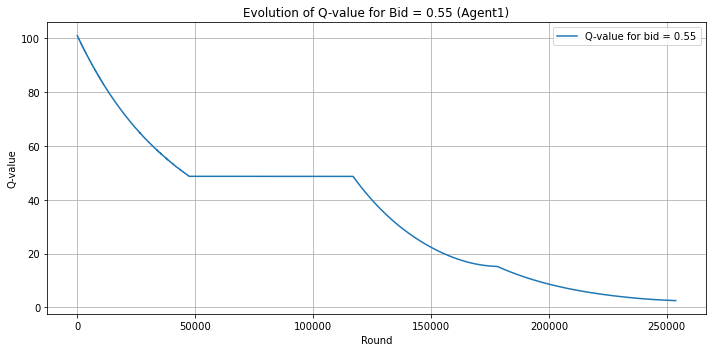

In [13]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 10

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.55")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.55 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### The evolution of the winning bid:

FPA

In [23]:
import numpy as np

def moving_average(data, window_size):
    return [np.mean(data[i:i+window_size]) for i in range(0, len(data) - window_size + 1)]

# Extract raw winning bids
winning_bids_fpa = [entry[2] for entry in history_FPA]
winning_bids_spa = [entry[2] for entry in history_SPA]

# Compute moving averages with window of 10
ma_fpa = moving_average(winning_bids_fpa, window_size=100)
ma_spa = moving_average(winning_bids_spa, window_size=100)

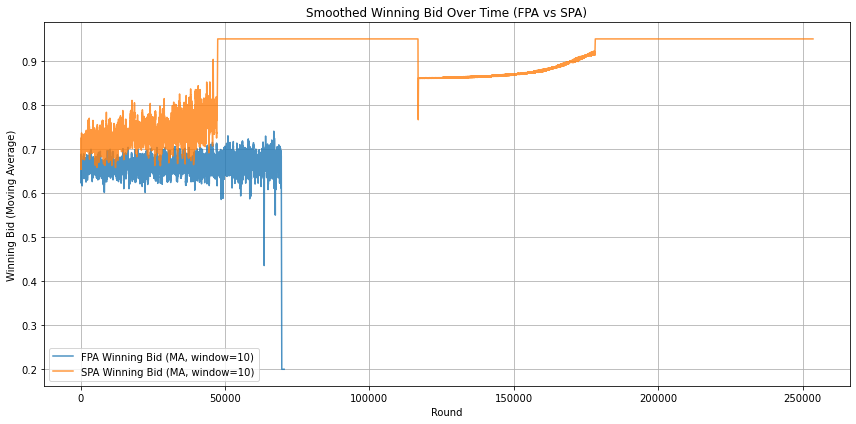

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(ma_fpa, label="FPA Winning Bid (MA, window=10)", alpha=0.8)
plt.plot(ma_spa, label="SPA Winning Bid (MA, window=10)", alpha=0.8)
plt.xlabel("Round")
plt.ylabel("Winning Bid (Moving Average)")
plt.title("Smoothed Winning Bid Over Time (FPA vs SPA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### General results from multiple simulations:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results = pd.read_csv("FPA_auction_summary_results.csv")

In [30]:
results.head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,77931,0.35,29.240635,0.35,30.062590
1,1,91825,0.40,26.429556,0.40,26.300220
2,2,78883,0.10,33.982775,0.10,34.712292
3,3,87492,0.25,29.588319,0.25,30.389061
4,4,86197,0.35,28.107094,0.35,28.263019


In [6]:
print("The mean bid converged to for agent 1 was ", results["converged_bid_Agent1"].mean())
print("The mean bid converged to for agent 2 was ", results["converged_bid_Agent2"].mean())

The mean bid converged to for agent 1 was  0.22750000000000006
The mean bid converged to for agent 2 was  0.22750000000000006


Exactly the same because they always converge to the same bid.

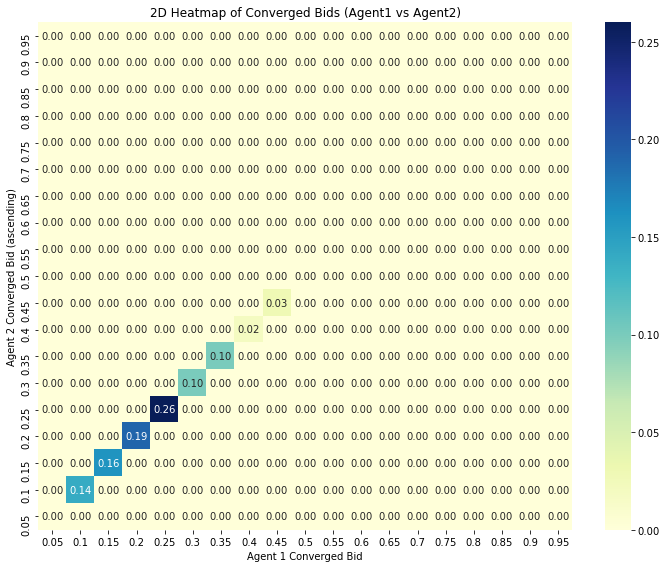

In [ ]:
import seaborn as sns

bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

for b1, b2 in zip(results["converged_bid_Agent1"], results["converged_bid_Agent2"]):
    heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
plt.title("2D Heatmap of Converged Bids (Agent1 vs Agent2)")
plt.xlabel("Agent 1 Converged Bid")
plt.ylabel("Agent 2 Converged Bid (ascending)")
plt.tight_layout()
plt.show()

The fact they always converge to the same bid can be seen as only values along the diagonal have any results.

In [33]:
mean_rounds = results["rounds_to_convergence"].mean()
print("Mean rounds to convergence:", mean_rounds)

Mean rounds to convergence: 77034.11


In [36]:
agent1_mean_q = results["converged_q_Agent1"].mean()
agent2_mean_q = results["converged_q_Agent2"].mean()

print("The mean q-value Agent1 converged to was", agent1_mean_q)
print("The mean q-value Agent2 converged to was", agent2_mean_q)

The mean q-value Agent1 converged to was 32.310272704193395
The mean q-value Agent2 converged to was 32.30355619999626


In [39]:
agent1_variance_q = results["converged_q_Agent1"].var()
agent2_variance_q = results["converged_q_Agent2"].var()

print("The variance of converged q-values for Agent1 was", agent1_variance_q)
print("The variance of converged q-values for Agent2 was", agent2_variance_q)

The variance of converged q-values for Agent1 was 6.786746749101875
The variance of converged q-values for Agent2 was 7.087259024066352


The q-value that the algorithms converge to are clearly drawn from the same distribution.

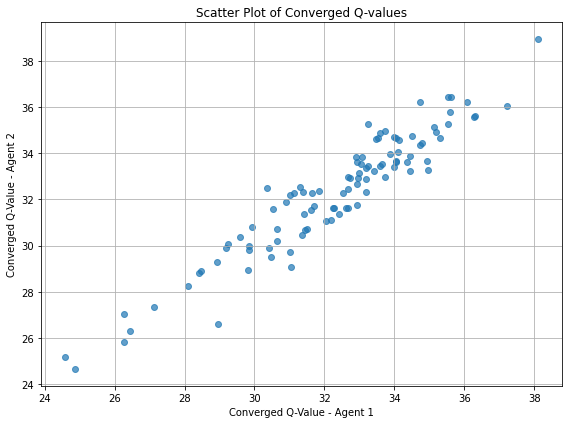

In [37]:
# Scatter plot: Agent 1 Q vs Agent 2 Q
plt.figure(figsize=(8, 6))
plt.scatter(results["converged_q_Agent1"], results["converged_q_Agent2"], alpha=0.7)
plt.title("Scatter Plot of Converged Q-values")
plt.xlabel("Converged Q-Value - Agent 1")
plt.ylabel("Converged Q-Value - Agent 2")
plt.grid(True)
plt.tight_layout()
plt.show()

Relationship is linear as expected.

##### Analysis for SPA:

In [7]:
results_SPA = pd.read_csv("SPA_auction_summary_results.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'SPA_auction_summary_results.csv'

In [41]:
results_SPA.head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2
0,0,243923,0.95,17.359193,0.95,2.509803
1,1,257225,0.95,16.870756,0.95,2.527931
2,2,238288,0.95,2.555876,0.95,16.307231
3,3,240071,0.95,2.544152,0.95,17.009763
4,4,241059,0.95,2.573469,0.95,21.570669


In [6]:
bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

for b1, b2 in zip(results_SPA["converged_bid_Agent1"], results_SPA["converged_bid_Agent2"]):
    heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=bid_options)
plt.title("2D Heatmap of Converged Bids (Agent1 vs Agent2)")
plt.xlabel("Agent 1 Converged Bid")
plt.ylabel("Agent 2 Converged Bid")
plt.tight_layout()
plt.show()

NameError: name 'results_SPA' is not defined

In [49]:
mean_rounds = results_SPA["rounds_to_convergence"].mean()
print("Mean rounds to convergence:", mean_rounds)

Mean rounds to convergence: 257089.91


In [51]:
agent1_mean_q = results_SPA["converged_q_Agent1"].mean()
agent2_mean_q = results_SPA["converged_q_Agent2"].mean()

print("The mean q-value Agent1 converged to was", agent1_mean_q)
print("The mean q-value Agent2 converged to was", agent2_mean_q)

The mean q-value Agent1 converged to was 9.391981439645361
The mean q-value Agent2 converged to was 10.268310736536225


In [53]:
agent1_variance_q = results_SPA["converged_q_Agent1"].var()
agent2_variance_q = results_SPA["converged_q_Agent2"].var()

print("The variance of converged q-values for Agent1 was", agent1_variance_q)
print("The variance of converged q-values for Agent2 was", agent2_variance_q)

The variance of converged q-values for Agent1 was 58.355088605548666
The variance of converged q-values for Agent2 was 57.79937054481531


Much greater variance in the q-values that the SPA converges to.

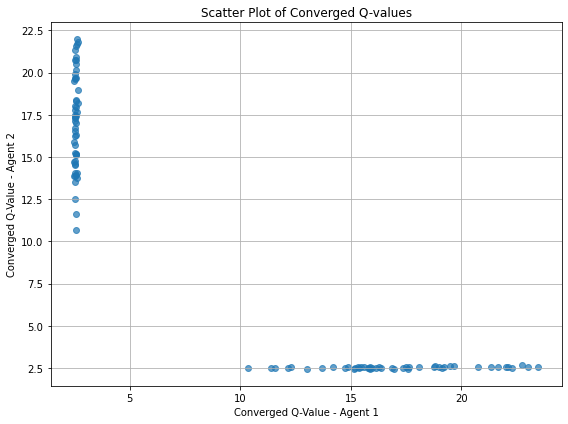

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(results_SPA["converged_q_Agent1"], results_SPA["converged_q_Agent2"], alpha=0.7)
plt.title("Scatter Plot of Converged Q-values")
plt.xlabel("Converged Q-Value - Agent 1")
plt.ylabel("Converged Q-Value - Agent 2")
plt.grid(True)
plt.tight_layout()
plt.show()

Completely different relationship of the convergence of the q-values. One always goes to around 2.5 and the other a greater value with more variability.

What's causing this behaviour?

### Asymmetry:

In this section I investigate if the collusive behaviour of the Q-learning agents is robust to the various asymmetries, which in practice we expect algorithms to have. These asymmetries can be present in the parameters of the agents, the learning rate $\alpha$, discount factor $\gamma$, the exploration rate $\epsilon$ and rate decay $\beta$. 

To begin with however I vary the value the bidders assign to the object they are bidding for. I retain Agent1's value as 1 and vary Agent2's value from 1 down to 0.4 in steps of 0.1. 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
value_095 = pd.read_csv("Results/value_asymmetry/FPA_value_0_95_results.csv")
value_09 = pd.read_csv("Results/value_asymmetry/FPA_value_0_9_results.csv")
value_085 = pd.read_csv("Results/value_asymmetry/FPA_value_0_85_results.csv")
value_08 = pd.read_csv("Results/value_asymmetry/FPA_value_0_8_results.csv")
value_075 = pd.read_csv("Results/value_asymmetry/FPA_value_0_75_results.csv")
value_07 = pd.read_csv("Results/value_asymmetry/FPA_value_0_7_results.csv")
value_065 = pd.read_csv("Results/value_asymmetry/FPA_value_0_65_results.csv")
value_06 = pd.read_csv("Results/value_asymmetry/FPA_value_0_6_results.csv")
value_055 = pd.read_csv("Results/value_asymmetry/FPA_value_0_55_results.csv")
value_05 = pd.read_csv("Results/value_asymmetry/FPA_value_0_5_results.csv")
value_045 = pd.read_csv("Results/value_asymmetry/FPA_value_0_45_results.csv")
value_04 = pd.read_csv("Results/value_asymmetry/FPA_value_0_4_results.csv")

dfs = [value_04, value_045, value_05, value_055, value_06, value_065, value_07, value_075, value_08, value_085, value_09, value_095]
agent2_values = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

In [26]:
total_runs = 100 #For each value of Agent2 there are 100 simulation

na_counts = [int(df['rounds_to_convergence'].isna().sum()) for df in dfs] #count the number of times no convergence occurs
converged_counts = [total_runs - na for na in na_counts]


print("NA counts by Agent2 value:", converged_counts)

NA counts by Agent2 value: [0, 0, 15, 40, 78, 99, 100, 100, 100, 100, 100, 100]


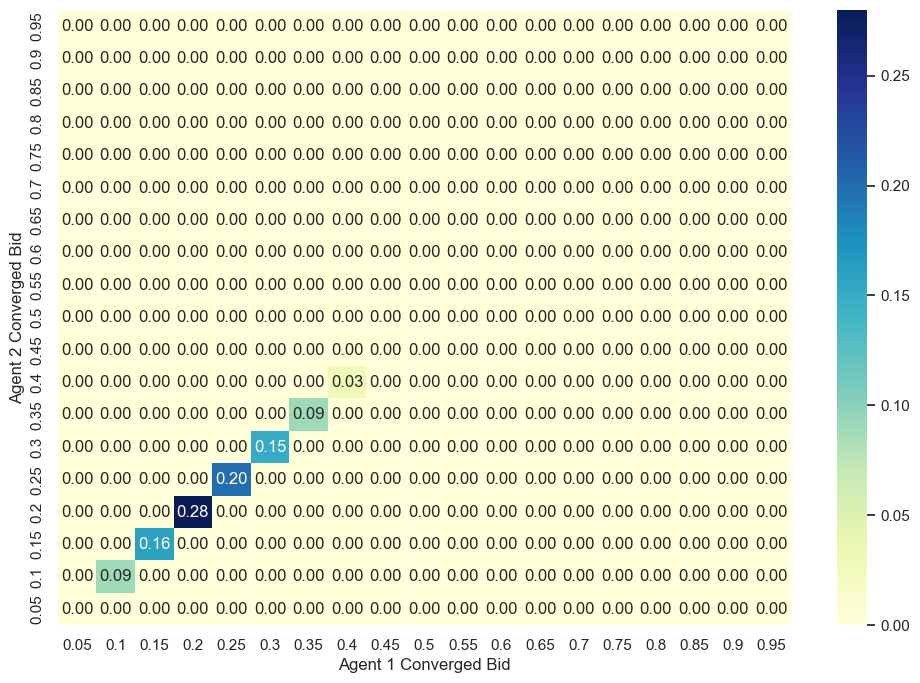

In [83]:
def plot_bid_heatmap(df, title=None):
    bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

    heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

    for b1, b2 in zip(df["converged_bid_Agent1"], df["converged_bid_Agent2"]):
        heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

    heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

    heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

    plt.figure(figsize=(10, 7))
    sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
    plt.xlabel("Agent 1 Converged Bid")
    plt.ylabel("Agent 2 Converged Bid")
    plt.tight_layout()
    #plt.savefig("v_asym_matrix_06.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_bid_heatmap(value_095, "Heatmap of final bids when Agent2 has value 0.55")

In simulations where Agent2's value is lower (stronger asymmetry) we notice that convergence occurs less and then not at all. This means that the agents are unable to collude. Instead Agent1 converges to the bid equal or just one increment more than Agent2's value while Agent2 is stuck decreasing its q-vector step-wise unable to find any bid which gives it a reward. 

/var/folders/dk/qrqx86bs0kx1bb06wpz1_5gr0000gn/T/ipykernel_6453/1082437479.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)


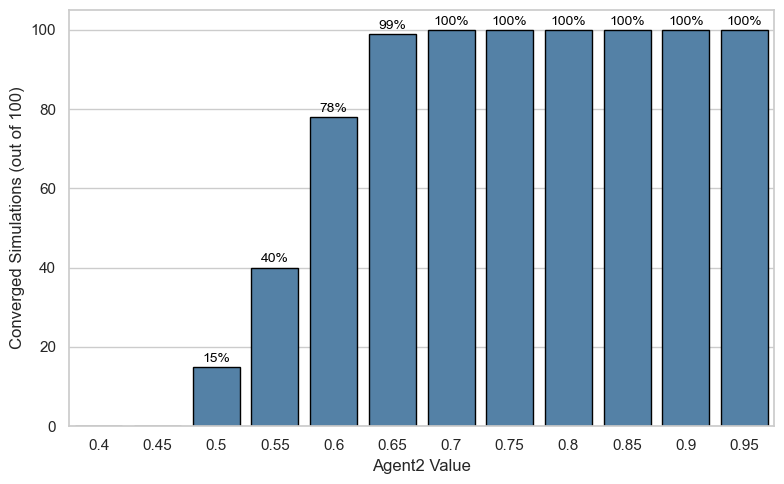

In [77]:
x_labels = [str(v) for v in agent2_values]

sns.set_theme(style="whitegrid")

# Plot with categorical x-axis (so each label lines up under its bar)
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=x_labels,                # categorical
    y=converged_counts,
    color="steelblue",
    edgecolor="black"
)

# Annotate each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}%",
        (p.get_x() + p.get_width() / 2, height-1.2),
        ha="center", va="bottom",
        fontsize=10, color="black",
        xytext=(0, 5), textcoords="offset points"
    )

ax.set_xlabel("Agent2 Value")
ax.set_ylabel("Converged Simulations (out of 100)")
ax.set_xticklabels(x_labels)

plt.tight_layout()
plt.savefig("convergene_percentage.pdf", format="pdf", bbox_inches="tight")
plt.show()



What is happening here. For Agent2's value small enough (<0.4) no more collusion occurs and Agent1 simply learns to bid Agent2's value

In [34]:
clean_value_04 = value_04[value_04['rounds_to_convergence'].notna()].copy()
clean_value_045 = value_045[value_045['rounds_to_convergence'].notna()].copy()
clean_value_05 = value_05[value_05['rounds_to_convergence'].notna()].copy()
clean_value_055 = value_055[value_055['rounds_to_convergence'].notna()].copy()
clean_value_06 = value_06[value_06['rounds_to_convergence'].notna()].copy()
clean_value_065 = value_065[value_065['rounds_to_convergence'].notna()].copy()

In [35]:
mean_bid_05 = clean_value_05['converged_bid_Agent1'].mean()
mean_bid_055 = clean_value_055['converged_bid_Agent1'].mean()
mean_bid_06 = clean_value_06['converged_bid_Agent1'].mean()
mean_bid_065 = clean_value_065['converged_bid_Agent1'].mean()
mean_bid_07 = value_07['converged_bid_Agent1'].mean()
mean_bid_075 = value_075['converged_bid_Agent1'].mean()
mean_bid_08 = value_08['converged_bid_Agent1'].mean()
mean_bid_085 = value_085['converged_bid_Agent1'].mean()
mean_bid_09 = value_09['converged_bid_Agent1'].mean()
mean_bid_095 = value_095['converged_bid_Agent1'].mean()


print(f"""
For value=0.5 the mean bid converged to is {mean_bid_05}
For value=0.55 the mean bid converged to is {mean_bid_055}
For value=0.6 the mean bid converged to is {mean_bid_06}
For value=0.65 the mean bid converged to is {mean_bid_065}
For value=0.7 the mean bid converged to is {mean_bid_07}
For value=0.75 the mean bid converged to is {mean_bid_075}
For value=0.8 the mean bid converged to is {mean_bid_08}
For value=0.85 the mean bid converged to is {mean_bid_085}
For value=0.9 the mean bid converged to is {mean_bid_09}""")


For value=0.5 the mean bid converged to is 0.15999999999999998
For value=0.55 the mean bid converged to is 0.14875
For value=0.6 the mean bid converged to is 0.1878205128205128
For value=0.65 the mean bid converged to is 0.206060606060606
For value=0.7 the mean bid converged to is 0.20850000000000002
For value=0.75 the mean bid converged to is 0.206
For value=0.8 the mean bid converged to is 0.21450000000000002
For value=0.85 the mean bid converged to is 0.22400000000000003
For value=0.9 the mean bid converged to is 0.20799999999999996


The mean bid converged to seems to decrease as the value of Agent2 decreases below 0.7. This is exactly when there are some simulations which do no manage to converge to a collusive strategy. It may be that those occasions in which the agents collude on relatively higher bids such as 0.4 are no longer possible with Agent 2's value being lower. In these instances no collusion is reached and Agent 1 learns to bid Agent 2's value. Want to better understand the learning and economic dynamics to understand why this is happening.

In [36]:
value_1 = pd.read_csv("Results/Initial results/FPA_auction_summary_results.csv")
mean_bid_1 = value_1["converged_bid_Agent1"].mean()
print(mean_bid_1)

0.22750000000000004


/var/folders/dk/qrqx86bs0kx1bb06wpz1_5gr0000gn/T/ipykernel_6453/1399690621.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1])


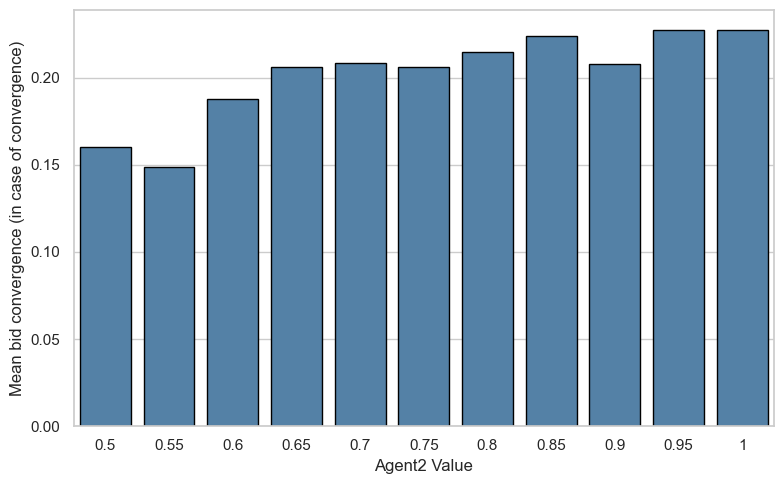

In [78]:
mean_bids = [mean_bid_05, mean_bid_055, mean_bid_06, mean_bid_065, mean_bid_07, mean_bid_075, mean_bid_08, mean_bid_085, mean_bid_09, mean_bid_095, mean_bid_1]

sns.set_theme(style="whitegrid")

# Plot with categorical x-axis (so each label lines up under its bar)
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1],                # categorical
    y=mean_bids,
    color="steelblue",
    edgecolor="black"
)

ax.set_xlabel("Agent2 Value")
ax.set_ylabel("Mean bid convergence (in case of convergence)")
ax.set_xticklabels([0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1])

plt.tight_layout()
plt.savefig("mean_bid_convergence.pdf", format="pdf", bbox_inches="tight")
plt.show()


$H_0$: The mean bid converged to by the agents when they one agent has lower values is **not lower** than when they have the same values. μ₂ ≥ μ₁

$H_1$: The mean bid converged to by the agents when they one agent has lower values is **lower** than when they have the same values. μ₂ < μ₁

Checking assumptions of test: normality and equal variance

/var/folders/dk/qrqx86bs0kx1bb06wpz1_5gr0000gn/T/ipykernel_6453/2678816137.py:27: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


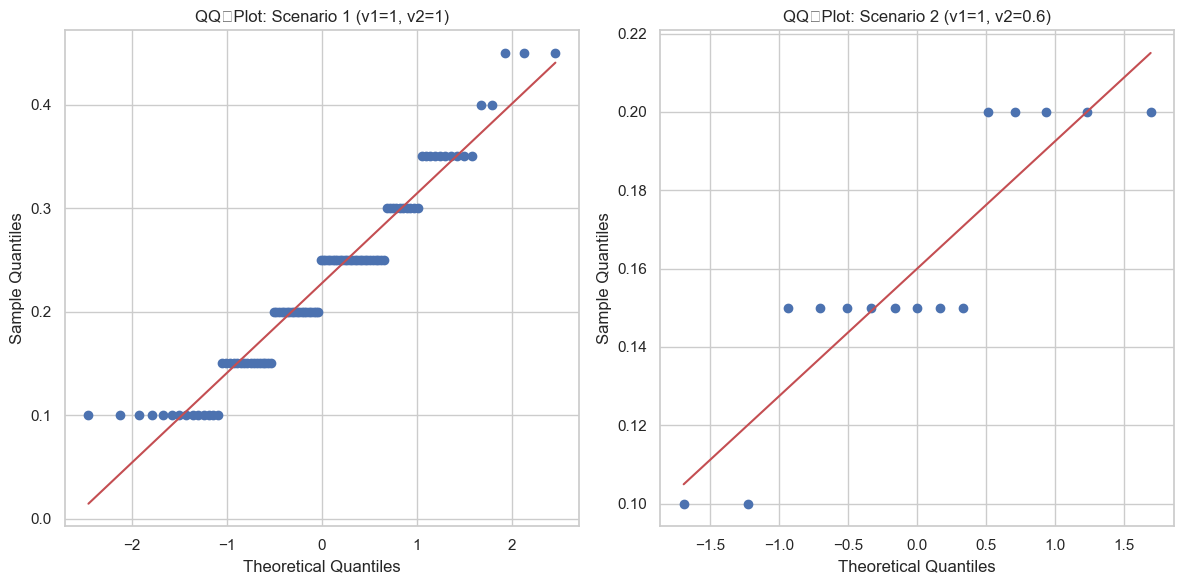

In [46]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# If you have two DataFrames, value_1 and value_2, each with 'converged_bid_Agent1'
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# QQ‐plot for Scenario 1
stats.probplot(
    value_1['converged_bid_Agent1'], 
    dist="norm", 
    plot=axes[0]
)
axes[0].set_title('QQ‐Plot: Scenario 1 (v1=1, v2=1)')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')

# QQ‐plot for Scenario 2
stats.probplot(
    clean_value_05['converged_bid_Agent1'], 
    dist="norm", 
    plot=axes[1]
)
axes[1].set_title('QQ‐Plot: Scenario 2 (v1=1, v2=0.6)')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()


In [79]:
print("Sample variance when agents are symmetric: ", value_1['converged_bid_Agent1'].var())
print("Sample variance when agents are asymmetric (Agent2 value = 0.9): ", value_09['converged_bid_Agent1'].var())
print("Sample variance when agents are asymmetric (Agent2 value = 0.8): ", value_08['converged_bid_Agent1'].var())
print("Sample variance when agents are asymmetric (Agent2 value = 0.7): ", value_07['converged_bid_Agent1'].var())
print("Sample variance when agents are asymmetric (Agent2 value = 0.6): ", clean_value_06['converged_bid_Agent1'].var())
print("Sample variance when agents are asymmetric (Agent2 value = 0.5): ", clean_value_05['converged_bid_Agent1'].var())

Sample variance when agents are symmetric:  0.007695707070707072
Sample variance when agents are asymmetric (Agent2 value = 0.9):  0.006298989898989899
Sample variance when agents are asymmetric (Agent2 value = 0.8):  0.00481287878787879
Sample variance when agents are asymmetric (Agent2 value = 0.7):  0.004497727272727272
Sample variance when agents are asymmetric (Agent2 value = 0.6):  0.0035185647685647683
Sample variance when agents are asymmetric (Agent2 value = 0.5):  0.001142857142857143


The data is relatively normal. The variances are similar however for the sake of safety a Welch's t-test is used to handle differences in the variance and sample sizes. 

In [48]:
from scipy import stats

def welch_t_test_lower(df1, df2, column="converged_bid_Agent1"):
    """
    Perform a one-sided Welch's t-test (H1: mean(df1) < mean(df2)).

    Parameters: Two dataframes and the column of interest.
    Returns: Test statistic and p-value
    """
    data1 = df1[column]
    data2 = df2[column]

    # Welch’s t-test (two-sided by default)
    t_stat, p_two_sided = stats.ttest_ind(data1, data2, equal_var=False)

    # Convert to one-sided (lower) p-value
    if t_stat < 0:
        p_value = p_two_sided / 2
    else:
        p_value = 1 - p_two_sided / 2

    return t_stat, p_value


In [54]:
def welch_t_test(df1, df2):
    """
    Perform a one-sided Welch's t-test between two pandas DataFrames.
    """
    
    data1 = df1['converged_bid_Agent1']
    data2 = df2['converged_bid_Agent1']

    # Perform Welch's t-test
    t_stat, two_p_value = stats.ttest_ind(data2, data1, equal_var=False) #Had to swap around order of data so that it tests in the correct direction

    if t_stat < 0:
        p_value = two_p_value / 2
    else:
        p_value = 1 - two_p_value / 2


    return t_stat, p_value

In [55]:
comparisons = [
    ("0.95", value_095),
    ("0.9", value_09),
    ("0.85", value_085),
    ("0.8", value_08),
    ("0.75", value_075),
    ("0.7", value_07),
    ("0.65", clean_value_065),
    ("0.6", clean_value_06),
    ("0.55", clean_value_055),
    ("0.5", clean_value_05),
]

for label, df in comparisons:
    t_stat, p_value = welch_t_test(value_1, df)
    print(
        f"Welch’s t-test (Agent2 value = {label}):\n"
        f"  • t-statistic       = {t_stat:.4f}\n"
        f"  • one-sided p-value = {p_value}\n"
    )

Welch’s t-test (Agent2 value = 0.95):
  • t-statistic       = -0.0000
  • one-sided p-value = 0.49999999999999906

Welch’s t-test (Agent2 value = 0.9):
  • t-statistic       = -1.6484
  • one-sided p-value = 0.05043991140830892

Welch’s t-test (Agent2 value = 0.85):
  • t-statistic       = -0.2908
  • one-sided p-value = 0.3857613072245662

Welch’s t-test (Agent2 value = 0.8):
  • t-statistic       = -1.1624
  • one-sided p-value = 0.12328205373448223

Welch’s t-test (Agent2 value = 0.75):
  • t-statistic       = -1.9542
  • one-sided p-value = 0.026092573843901658

Welch’s t-test (Agent2 value = 0.7):
  • t-statistic       = -1.7206
  • one-sided p-value = 0.043492716531532305

Welch’s t-test (Agent2 value = 0.65):
  • t-statistic       = -1.9057
  • one-sided p-value = 0.029108133415127916

Welch’s t-test (Agent2 value = 0.6):
  • t-statistic       = -3.5914
  • one-sided p-value = 0.0002142286648909926

Welch’s t-test (Agent2 value = 0.55):
  • t-statistic       = -7.0894
  • one-si

In [93]:
import pandas as pd

df_symmetric = pd.read_csv("Results_FPA/3bidders/Initial results/FPA_3bidder_initial_results.csv")
df_09 = pd.read_csv("Results_FPA/3bidders/value_asymmetry/FPA_3bidder_value1_0.9.csv")
df_08 = pd.read_csv("Results_FPA/3bidders/value_asymmetry/FPA_3bidder_value1_0.8_results.csv")
df_07 = pd.read_csv("Results_FPA/3bidders/value_asymmetry/FPA_3bidder_value1_0.7_results.csv")
df_06 = pd.read_csv("Results_FPA/3bidders/value_asymmetry/FPA_3bidder_value1_0.6_results.csv")

In [86]:
df_09.head()

,simulation_id,rounds_to_convergence,converged_bid_Agent1,converged_q_Agent1,converged_bid_Agent2,converged_q_Agent2,converged_bid_Agent3,converged_q_Agent3
0,0,212010.0,0.85,5.283097,0.85,5.120916,0.85,1.188007
1,1,111905.0,0.50,14.124662,0.50,14.795859,0.50,10.740072
2,2,204246.0,0.65,7.803457,0.65,7.989198,0.65,3.922488
3,3,120844.0,0.40,14.409455,0.40,15.846729,0.40,11.045813
4,4,204602.0,0.80,5.931668,0.80,5.850531,0.80,1.935283


In [88]:
# Suppose your DataFrame is called df
# Step 1: pick out the bid columns
bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2", "converged_bid_Agent3"]

# Step 2: compute the row-wise maximum across those columns
df_09["max_bid_per_sim"] = df_09[bid_cols].max(axis=1)

# Step 3: compute the mean of those maxima
mean_of_max_bids = df_09["max_bid_per_sim"].mean()

print("Mean of highest converged bids across simulations:", mean_of_max_bids)

Mean of highest converged bids across simulations: 0.6985000000000001


In [89]:
# Suppose your DataFrame is called df
# Step 1: pick out the bid columns
bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2", "converged_bid_Agent3"]

# Step 2: compute the row-wise maximum across those columns
df_symmetric["max_bid_per_sim"] = df_symmetric[bid_cols].max(axis=1)

# Step 3: compute the mean of those maxima
mean_of_max_bids = df_symmetric["max_bid_per_sim"].mean()

print("Mean of highest converged bids across simulations:", mean_of_max_bids)

Mean of highest converged bids across simulations: 0.7055


In [92]:
bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2", "converged_bid_Agent3"]

# Step 2: compute the row-wise maximum across those columns
df_08["max_bid_per_sim"] = df_08[bid_cols].max(axis=1)

# Step 3: compute the mean of those maxima
mean_of_max_bids = df_08["max_bid_per_sim"].mean()

print("Mean of highest converged bids across simulations:", mean_of_max_bids)

Mean of highest converged bids across simulations: 0.6609999999999999


In [94]:
bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2", "converged_bid_Agent3"]

# Step 2: compute the row-wise maximum across those columns
df_07["max_bid_per_sim"] = df_07[bid_cols].max(axis=1)

# Step 3: compute the mean of those maxima
mean_of_max_bids = df_07["max_bid_per_sim"].mean()

print("Mean of highest converged bids across simulations:", mean_of_max_bids)

Mean of highest converged bids across simulations: 0.6495000000000002


In [95]:
bid_cols = ["converged_bid_Agent1", "converged_bid_Agent2", "converged_bid_Agent3"]

# Step 2: compute the row-wise maximum across those columns
df_06["max_bid_per_sim"] = df_06[bid_cols].max(axis=1)

# Step 3: compute the mean of those maxima
mean_of_max_bids = df_06["max_bid_per_sim"].mean()

print("Mean of highest converged bids across simulations:", mean_of_max_bids)

Mean of highest converged bids across simulations: 0.606
